In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Segnature Inference

In [2]:
class ResultsEvaluation:
    
    def __init__(self, file_name):
        self.evaluations_df = json.load(open(f'../results/{file_name}.json'))
        self.run_labels, self.sampling_labels, self.signature_labels = self.get_runs_sample_labels()
        self.per_run_accuracy = self.get_runs_sample_metrics('accuracy')
        self.per_run_balanced_accuracy = self.get_runs_sample_metrics('balanced_accuracy')
        self.per_run_f1_score = self.get_runs_sample_metrics('f1')
        self.per_run_mcc = self.get_runs_sample_metrics('mcc')
        
    def get_runs_sample_labels(self):
        run_labels = []
        for run in list(self.evaluations_df.keys()):
            if self.evaluations_df[run]['sampling_0.01'] != {}:
                run_labels.append(run)  

        sampling_labels = self.evaluations_df[run_labels[0]].keys()
        sampling_labels = list(sampling_labels)
        signature_labels = []
        for i in range(len(self.evaluations_df[run_labels[0]][sampling_labels[0]])):
            signature_labels.append(self.evaluations_df[run_labels[0]][sampling_labels[0]][i]['signature'])

        return run_labels, sampling_labels, signature_labels
    
    def get_metrics(self, run, sample, signature, metrics):
        return self.evaluations_df[run][sample][self.signature_labels.index(signature)]['best_model_metrics'][metrics]
    
    def get_runs_sample_metrics(self, metrics):
        run_labels, sampling_labels, signature_labels = self.get_runs_sample_labels() 
        per_run_metric = []
        for run in run_labels:
            per_sample_metric = []
            for sampling in sampling_labels:
                per_signature_metric = []
                for i in range(len(signature_labels)):
                    per_signature_metric.append(self.evaluations_df[run][sampling][i]['best_model_metrics'][metrics])# Save the accuracy of each signarure for one sample

                per_sample_metric.append(per_signature_metric)
            per_run_metric.append(per_sample_metric)
        return per_run_metric

In [3]:
def heat_map(rs, f):
    x_labels = rs.sampling_labels
    y_labels = rs.signature_labels

    ra = rs.get_runs_sample_metrics('accuracy')  # shape: [num_runs][num_sampling][num_signature]

    # Converti in array numpy e calcola la media sulle run (asse 0)
    ra = np.array(ra)
    mean_accuracy = np.mean(ra, axis=0)  # shape: [num_sampling][num_signature]

    # Crea un DataFrame per la heatmap
    df = pd.DataFrame(mean_accuracy.T, index=y_labels, columns=x_labels)  # trasposta per avere signature come righe

    plt.figure(figsize=(10, max(0.21 * len(rs.signature_labels),15)))
    ax = sns.heatmap(df, annot=False, fmt=".2f", cmap="viridis")
    plt.xlabel("Sampling Method")
    plt.ylabel("Signature Type")
    plt.title(f"Average Balanced Accuracy for {f}")

    # Annotazioni personalizzate
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            value = df.iloc[i, j]
            color = 'red' if np.isclose(value, 0.5) else 'white'  # usa white o altro colore per il resto
            ax.text(j + 0.5, i + 0.5, f"{value:.2f}", ha='center', va='center', color=color)

    plt.tight_layout()
    plt.show()
    
def plot_standard_deviations(rs, f):
    m = np.array(rs.per_run_balanced_accuracy)
    std = np.std(m, axis=0)
    plt.figure(figsize=(max(0.5 * len(std[0]),15), 6))
    ax = sns.heatmap(std, xticklabels=rs.signature_labels, yticklabels=rs.sampling_labels, cmap='viridis', annot=True, fmt=".2f")
    plt.xlabel("Signature Labels")
    plt.ylabel("Sampling Labels")
    plt.title(f"Standard Deviation of Per-Run Accuracy {f}")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
def plot_per_run_metric(re, attr_name="per_run_accuracy", metric_name="Accuracy"):
    metric = getattr(re, attr_name)
    
    per_run_mean_metric = []
    for i in range(len(metric)):      
        per_sample_mean = []
        for j in range(len(metric[i])):
            per_sample_mean.append(np.mean(metric[i][j]))
        per_run_mean_metric.append(per_sample_mean)
    
    per_run_mean_metric = np.array(per_run_mean_metric)
    
    means = per_run_mean_metric.mean(axis=0)
    plt.plot(re.sampling_labels, means, marker='o', label=metric_name)
    plt.xticks(rotation=90)
    plt.ylabel(metric_name)
    plt.xlabel("Sampling Level")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
def plot_violins(re):
    plt.figure(figsize=(20, 10))
    per_run_accuracy = np.array(re.per_run_accuracy)
    plt.xlabel('Sampling')
    plt.xticks(range(1, len(re.sampling_labels) + 1), re.sampling_labels, rotation=90)
    plt.ylabel('Accuracy')
    plt.title('Violin Plot of Accuracy Across Runs')
    plt.violinplot([per_run_accuracy[:, j, :].flatten() for j in range(len(re.sampling_labels))], showmeans=True, showmedians=True, showextrema=True)
    
def plot_boxplot_accuracy_by_sampling(rss, files):
    data = []
    runs = {}
    for rs, name in zip(rss, files):
        runs[name] = rs

    for run_name, run_obj in runs.items():
        for samp_idx, sampling in enumerate(run_obj.sampling_labels):
            accs = run_obj.per_run_accuracy[0][samp_idx]  # solo un run per oggetto
            for acc in accs:
                data.append({
                    'sampling': sampling,
                    'balanced_accuracy': acc,
                    'run': run_name
                })

    df = pd.DataFrame(data)

    plt.figure(figsize=(14, 6))
    sns.boxplot(x='sampling', y='balanced_accuracy', hue='run', data=df)
    plt.xticks(rotation=90)
    plt.title('Balanced Accuracy per Sampling Level (per Signature)')
    plt.tight_layout()
    plt.show()
    
def get_signature_mean_per_run(re, label):
    # Ottieni la lista delle signature
    signature_labels = re.signature_labels
    sig_acc = {sig: [] for sig in signature_labels}

    for run in re.per_run_accuracy:
        for sig_idx, sig in enumerate(signature_labels):
            # Media sui livelli di sampling
            sig_bal_acc = np.mean([sampling[sig_idx] for sampling in run])
            sig_acc[sig].append(sig_bal_acc)

    return pd.DataFrame(sig_acc, index=[label])

def plot_signature_heatmap(rss, files):
    runs = {}
    for rs, name in zip(rss, files):
        runs[name] = rs

    # Preparo la struttura per il DataFrame
    data = { run_name: [] for run_name in runs }
    signatures = rss[0].signature_labels

    for run_name, run_obj in runs.items():
        # per ogni signature, raccolgo tutte le balanced_accuracy su tutti i sampling
        for sig_idx, sig in enumerate(signatures):
            vals = []
            for samp_idx in range(len(run_obj.sampling_labels)):
                vals.append(run_obj.per_run_accuracy[0][samp_idx][sig_idx])
            data[run_name].append(np.mean(vals))

    df = pd.DataFrame(data, index=signatures)

    # Plotto la heatmap
    plt.figure(figsize=(8,10))
    sns.heatmap(df, annot=True, fmt=".3f", cbar_kws={'label': 'Mean Balanced Accuracy'})
    plt.title('Mean Balanced Accuracy per Signature e Run')
    plt.ylabel('Signature')
    plt.xlabel('Run strategy')
    plt.tight_layout()
    plt.show()
    
def plot_evaluation_ensamble(rs):
    fig, axes = plt.subplots(4, 4, figsize=(60, 30))
    axes = axes.flatten()

    for plot_idx, sampling in enumerate(rs.sampling_labels):
        rows = []
        for i, sig in enumerate(rs.signature_labels):
            df = pd.DataFrame(rs.evaluations_df['run_1'][sampling][i]['ensemble_info'])
            for _, row in df.iterrows():
                rows.append({
                    'signature': sig,
                    'model': row['model_name'],
                    'val_score': row['val_score']
                })
            rows.append({
                'signature': sig,
                'model': 'total_accuracy',
                'val_score': rs.evaluations_df['run_1'][sampling][i]['best_model_val_score']
        })

        # Genera il grafico per il subplot corrente
        df_plot = pd.DataFrame(rows)
        processed = []

        for sig, group in df_plot.groupby('signature'):
            sorted_group = group.sort_values('val_score')
            prev = 0
            for _, row in sorted_group.iterrows():
                height = row['val_score'] - prev
                processed.append({
                    'signature': sig,
                    'model': row['model'],
                    'height': height
                })
                prev = row['val_score']

        df_stacked = pd.DataFrame(processed)
        # Pivot e riordino delle colonne
        df_pivot = df_stacked.pivot_table(index='signature', columns='model', values='height', fill_value=0)
        df_pivot.plot(kind='bar', stacked=True, colormap='Dark2', ax=axes[plot_idx])
        axes[plot_idx].set_title(f"Sampling: {sampling}")
        axes[plot_idx].set_ylabel("Max Validation Score")
        axes[plot_idx].set_xlabel("Signature")
        axes[plot_idx].legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()

def plot_all_signature_all_sampling_graph(re, folder_name=None, bins = False):
    per_run_accuracy = np.array(re.per_run_balanced_accuracy)
    mean_accuracy = np.mean(per_run_accuracy, axis=0)

    fig, ax1 = plt.subplots()
    plt.title('Average Accuracy per Signature (Averaged Across Runs)')
    # Plotta la media per ogni campione (dimensione j di per_sample_accuracy)
    for j in range(len(mean_accuracy)):
        plt.plot(re.signature_labels, mean_accuracy[j], marker='o', label=re.sampling_labels[j])

    legend = fig.legend(re.sampling_labels, )
    legend.set_loc('outside upper right')
    ax1.set_xlabel('Signature')
    ax1.set_xticks(ax1.get_xticks())
    ax1.set_xticklabels(ax1.get_xticks(), rotation=45, ha='right')
    ax1.set_ylabel('Average Accuracy')
    if bins:
        ax2 = ax1.twinx()
        signature_gt_path = f'../simulations/ground_truth{folder_name}/bin_exposures.csv'
        signature_gt_df = pd.read_csv(signature_gt_path)
        active_segnature = signature_gt_df.iloc[:, 1:].sum()
        active_segnature.plot(kind='bar', alpha=0.7, color='gray', ax=ax2)
        ax2.set_ylabel('Number of samples for segnature')
        
    fig.set_figheight(10)
    fig.set_figwidth(max(0.25 * len(active_segnature),15))
    plt.tight_layout()
    plt.show()

# Graphs

### Signautres Count

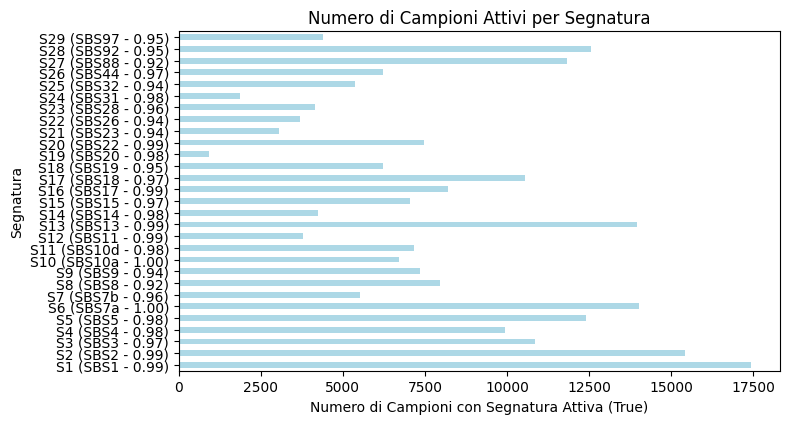

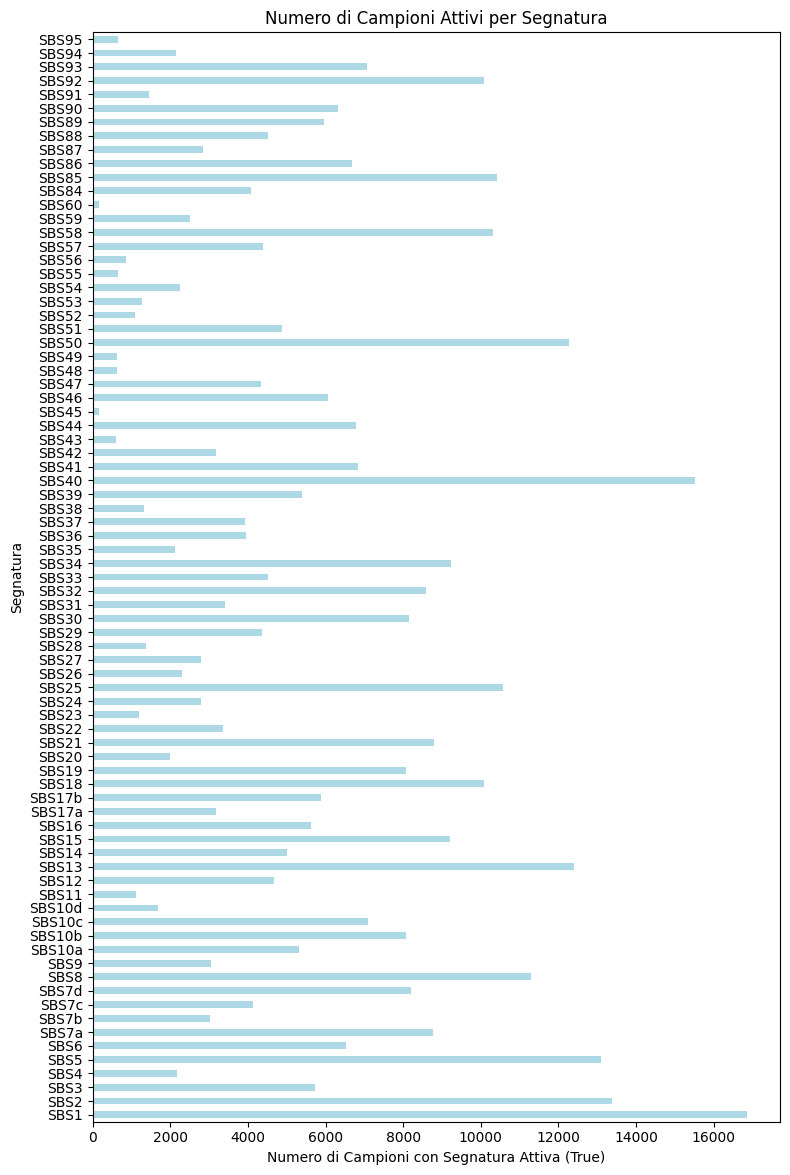

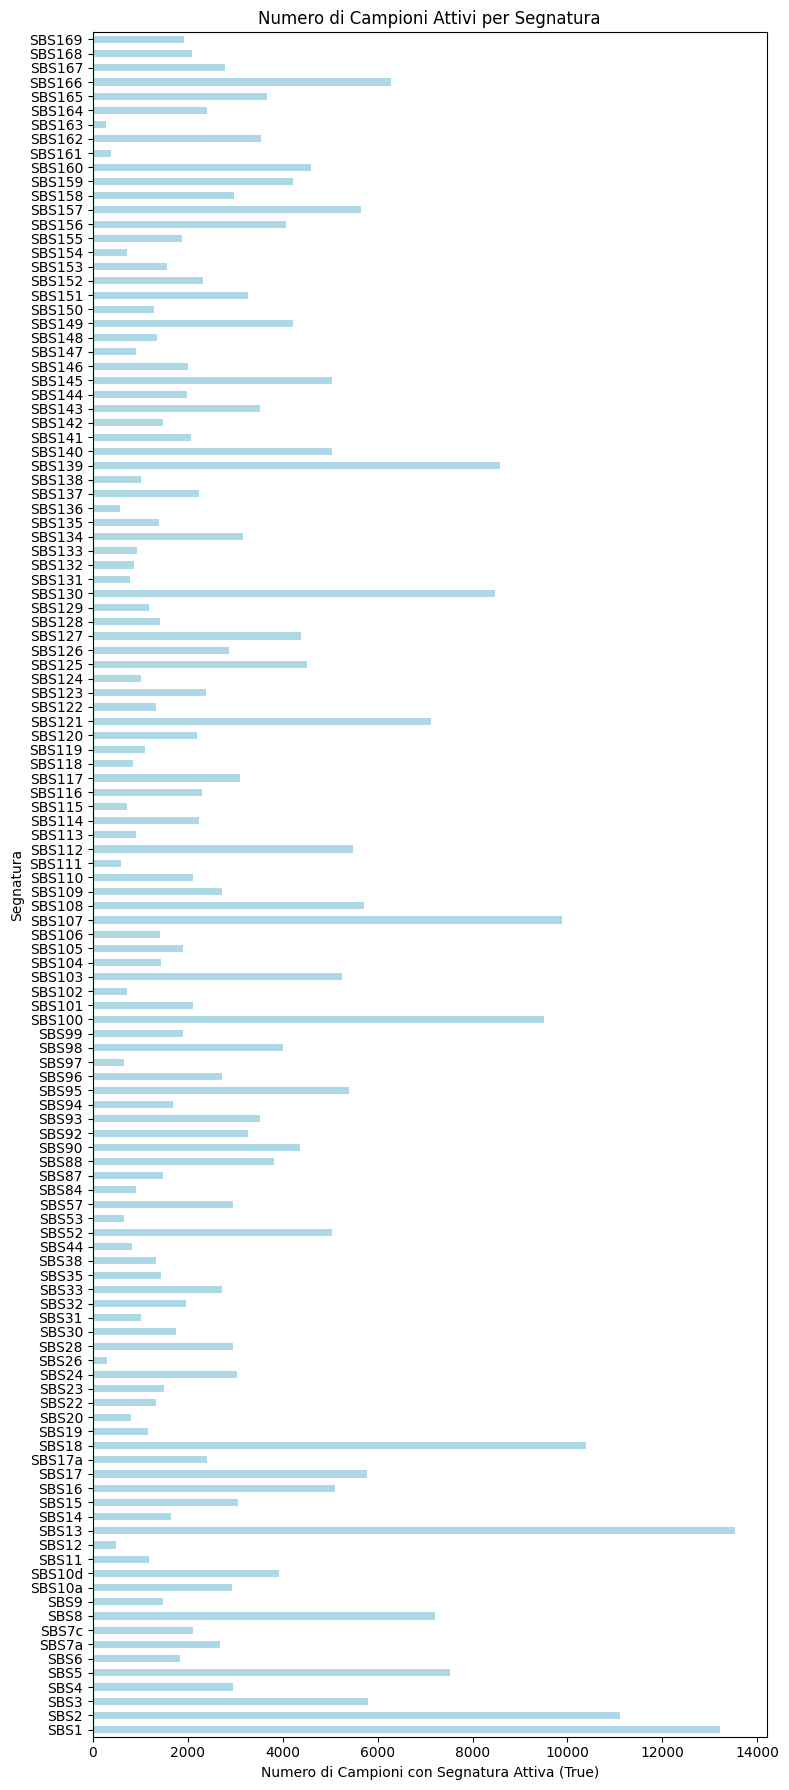

In [4]:
def number_of_sample_per_signature(folder_name):
    signature_gt_path = f'../simulations/ground_truth{folder_name}/bin_exposures.csv'

    signature_gt_df = pd.read_csv(signature_gt_path)
    active_segnature = signature_gt_df.iloc[:, 1:].sum()

    plt.figure(figsize=(8, 0.15*len(active_segnature)))
    active_segnature.plot(kind='barh', color='lightblue')
    plt.ylabel('Segnatura')
    plt.xlabel('Numero di Campioni con Segnatura Attiva (True)')
    plt.title('Numero di Campioni Attivi per Segnatura')
    plt.tight_layout()
    plt.show()
    
number_of_sample_per_signature('')
number_of_sample_per_signature('_cosmic')
number_of_sample_per_signature('_reference')


## Analysis the Ensamble of Models

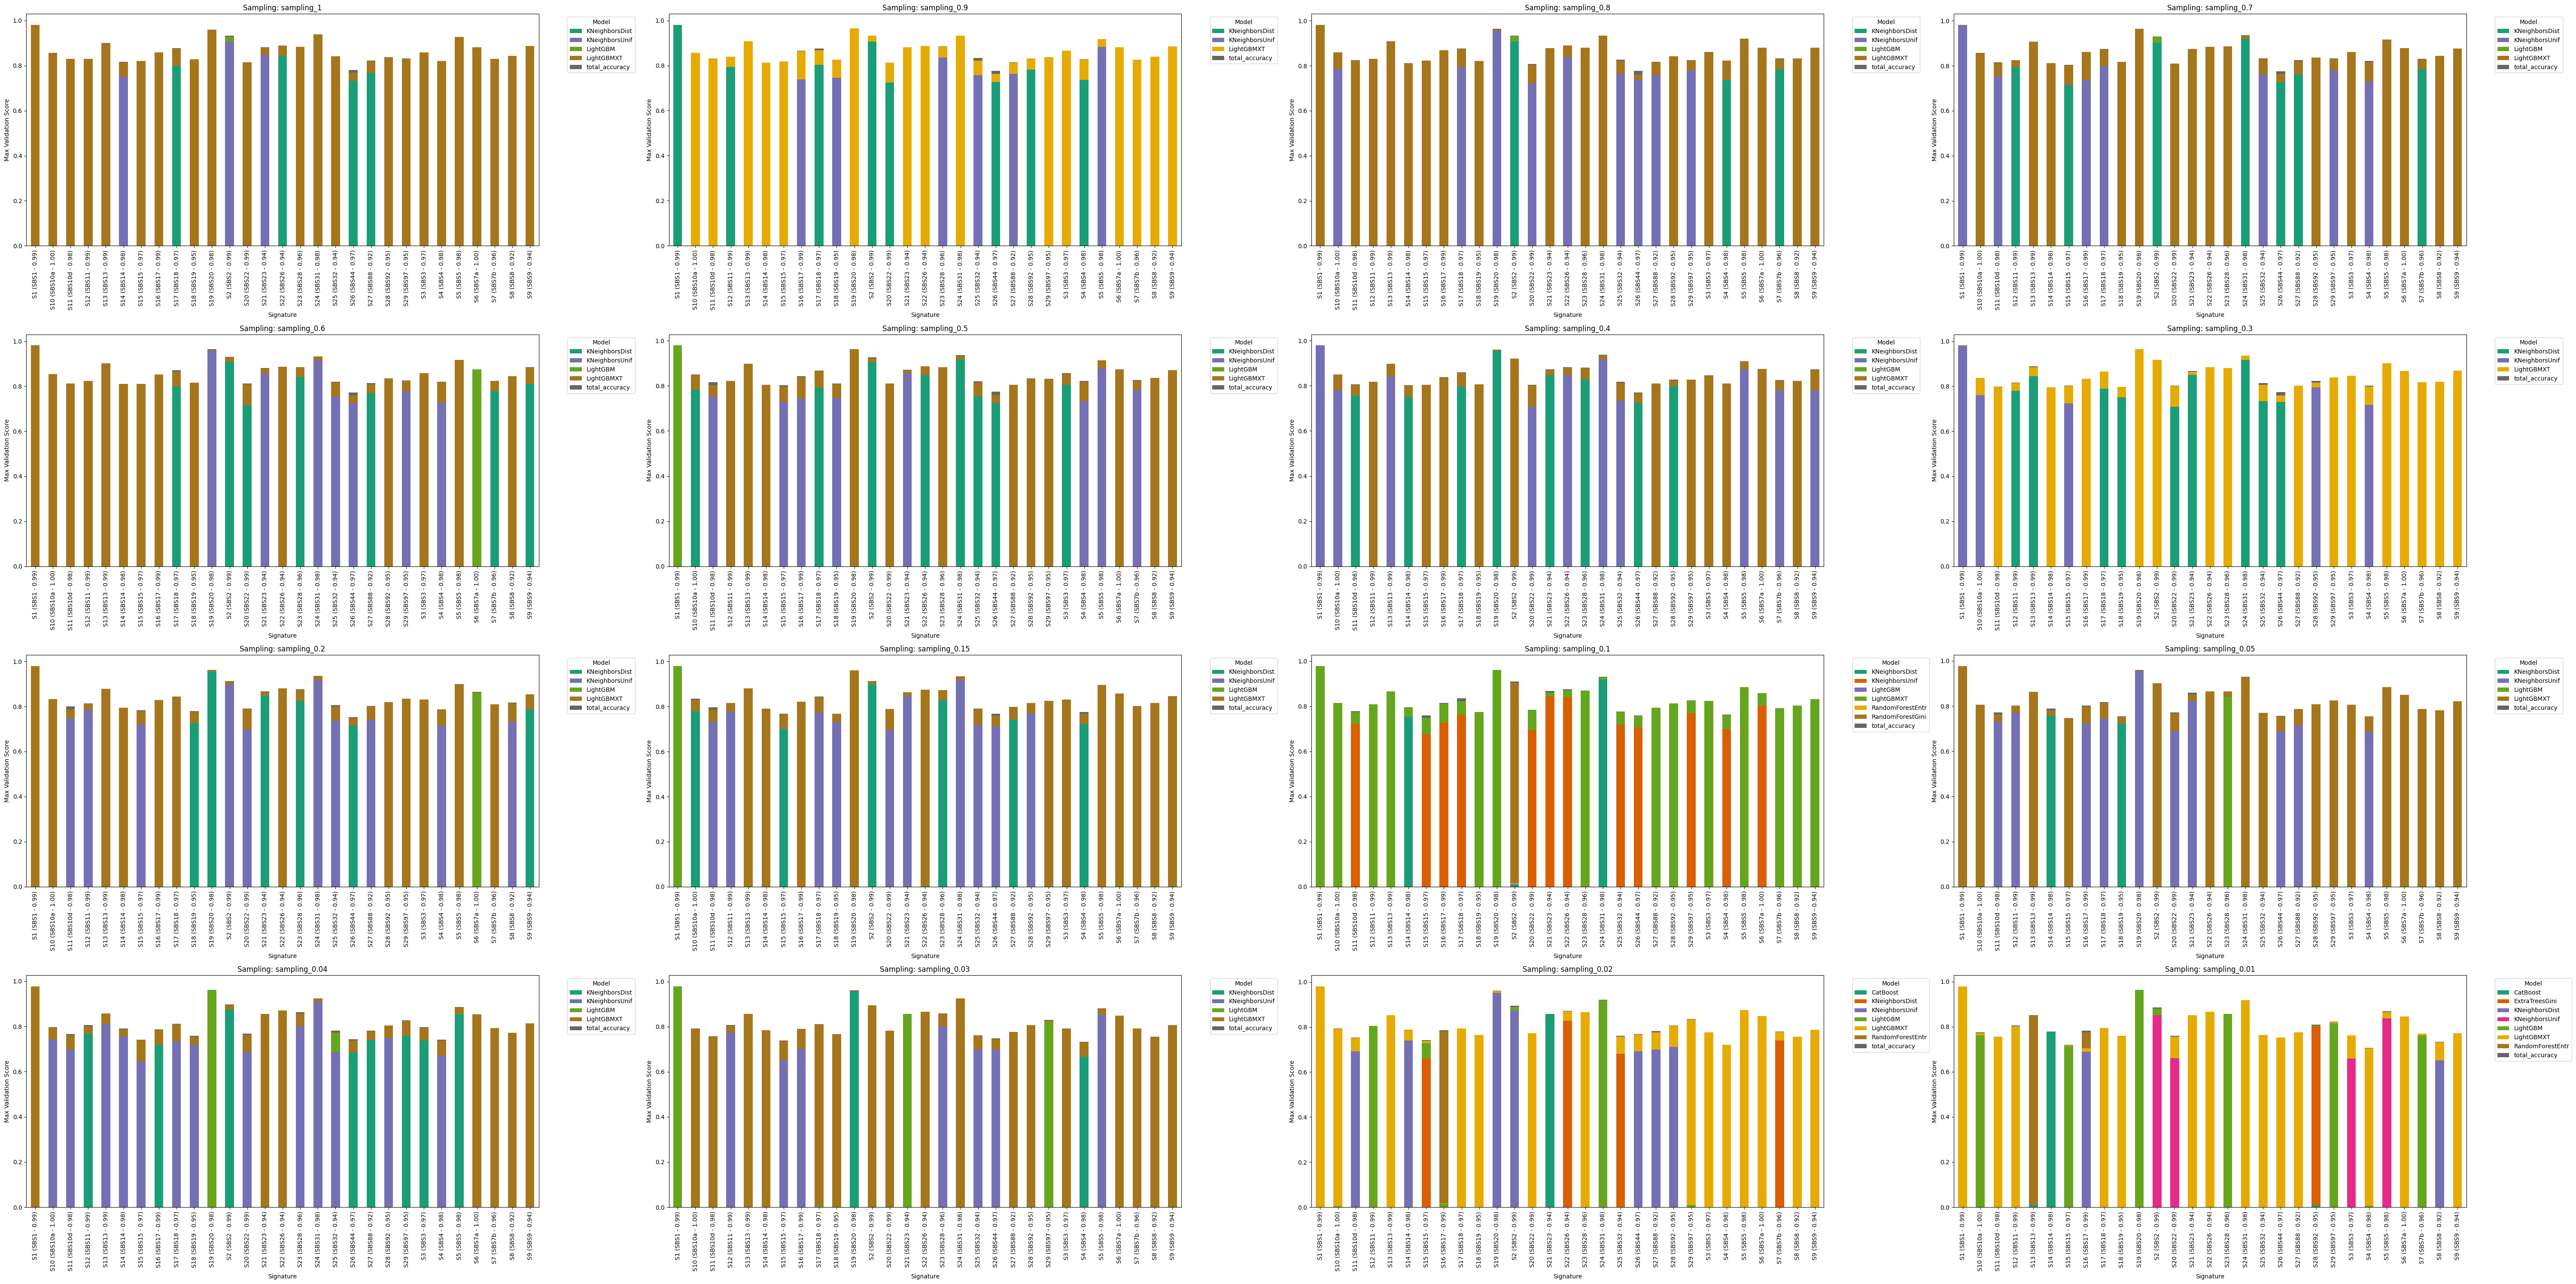

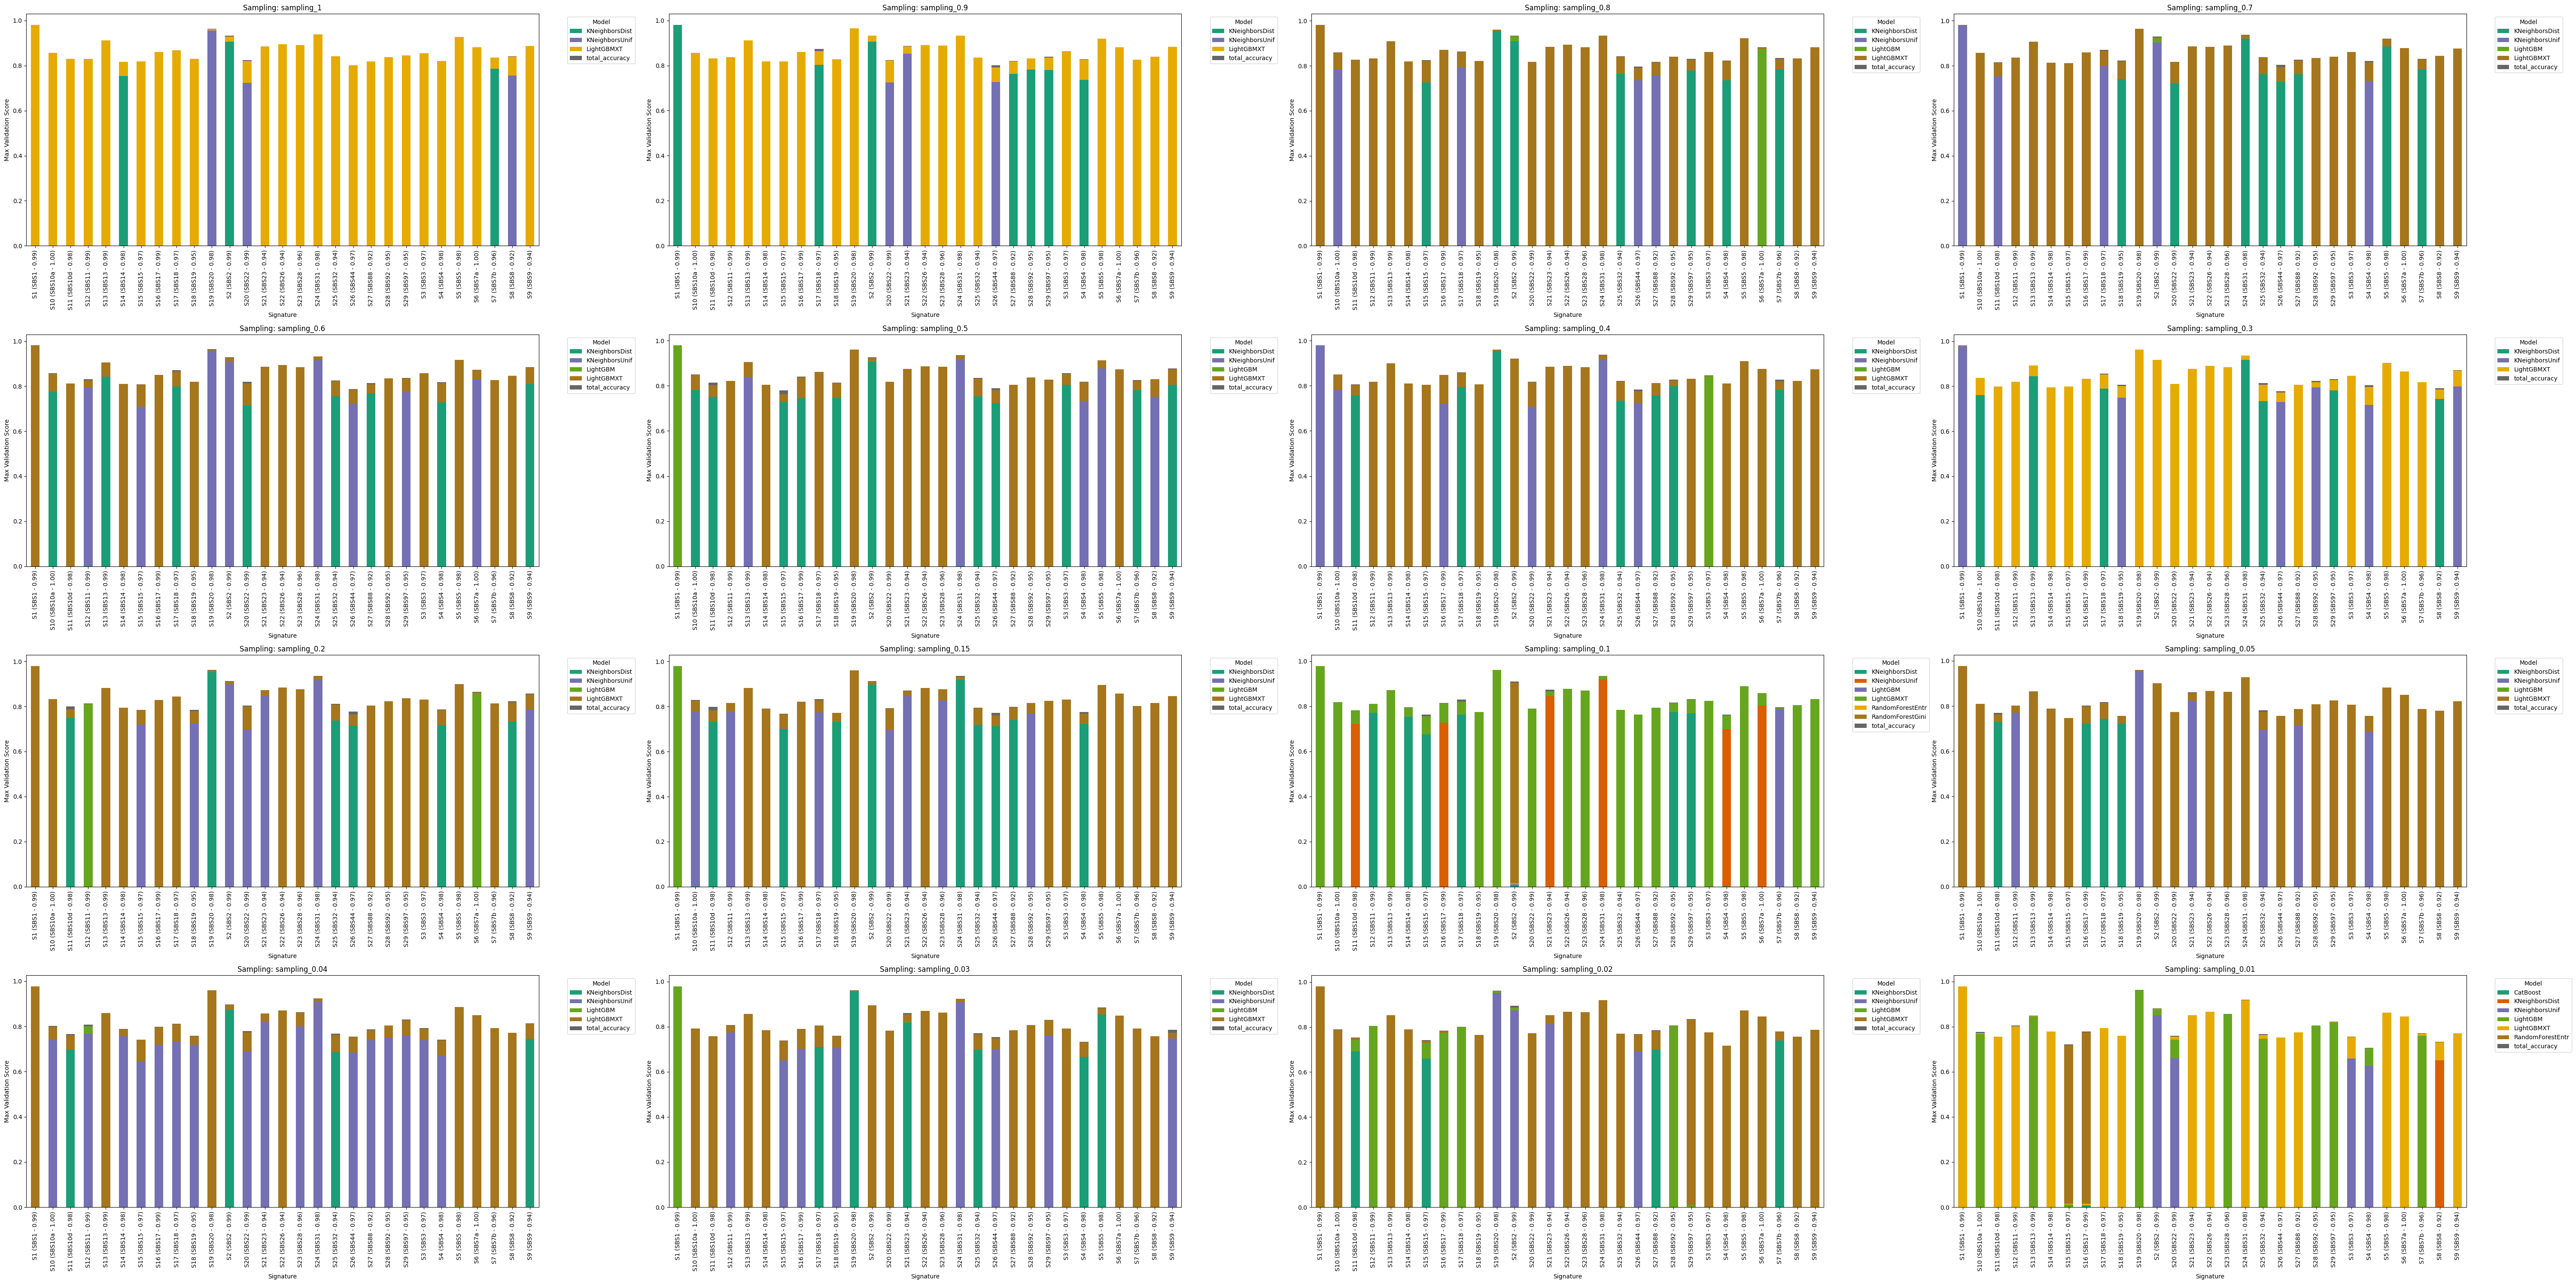

In [5]:
correlated_ensamble = ResultsEvaluation('./tries/default_correlated_evaluations')
uncorrelated_ensamble = ResultsEvaluation('./tries/default_non_correlated_evaluations')
plot_evaluation_ensamble(correlated_ensamble)
plot_evaluation_ensamble(uncorrelated_ensamble)

## Which model is the best?

In [6]:
from collections import defaultdict

run1 = correlated_ensamble.evaluations_df['run_1']
position_counts = defaultdict(lambda: defaultdict(int))

for sampling in run1.values():
    for sig in sampling:
        for pos, model in enumerate(sig['ensemble_models'], start=1):
            position_counts[pos][model] += 1

# Convertiamo in DataFrame
df = pd.DataFrame(position_counts).T.fillna(0).astype(int)
df.index.name = 'Position'
df.columns.name = 'Model'

df

Model,LightGBMXT,KNeighborsDist,LightGBM,KNeighborsUnif,RandomForestEntr,CatBoost,ExtraTreesGini,RandomForestGini
Position,,,,,,,,
1,446,3,9,1,1,4,0,0
2,0,77,17,134,3,1,1,0
3,0,39,9,0,0,0,0,0
4,0,0,3,0,0,0,0,1


### Confront between the best model, the ensamble and the non correlated version

In [7]:
rss_tries = []
def_corr_rs = ResultsEvaluation('tries/default_correlated_evaluations')
def_uncorr_rs = ResultsEvaluation('tries/default_non_correlated_evaluations')
def_light = ResultsEvaluation('tries/default_light_evaluations')

files = ['Correlated', 'Uncorrelated', 'LightGBMXT']

rss_tries = [def_uncorr_rs, def_corr_rs, def_light]

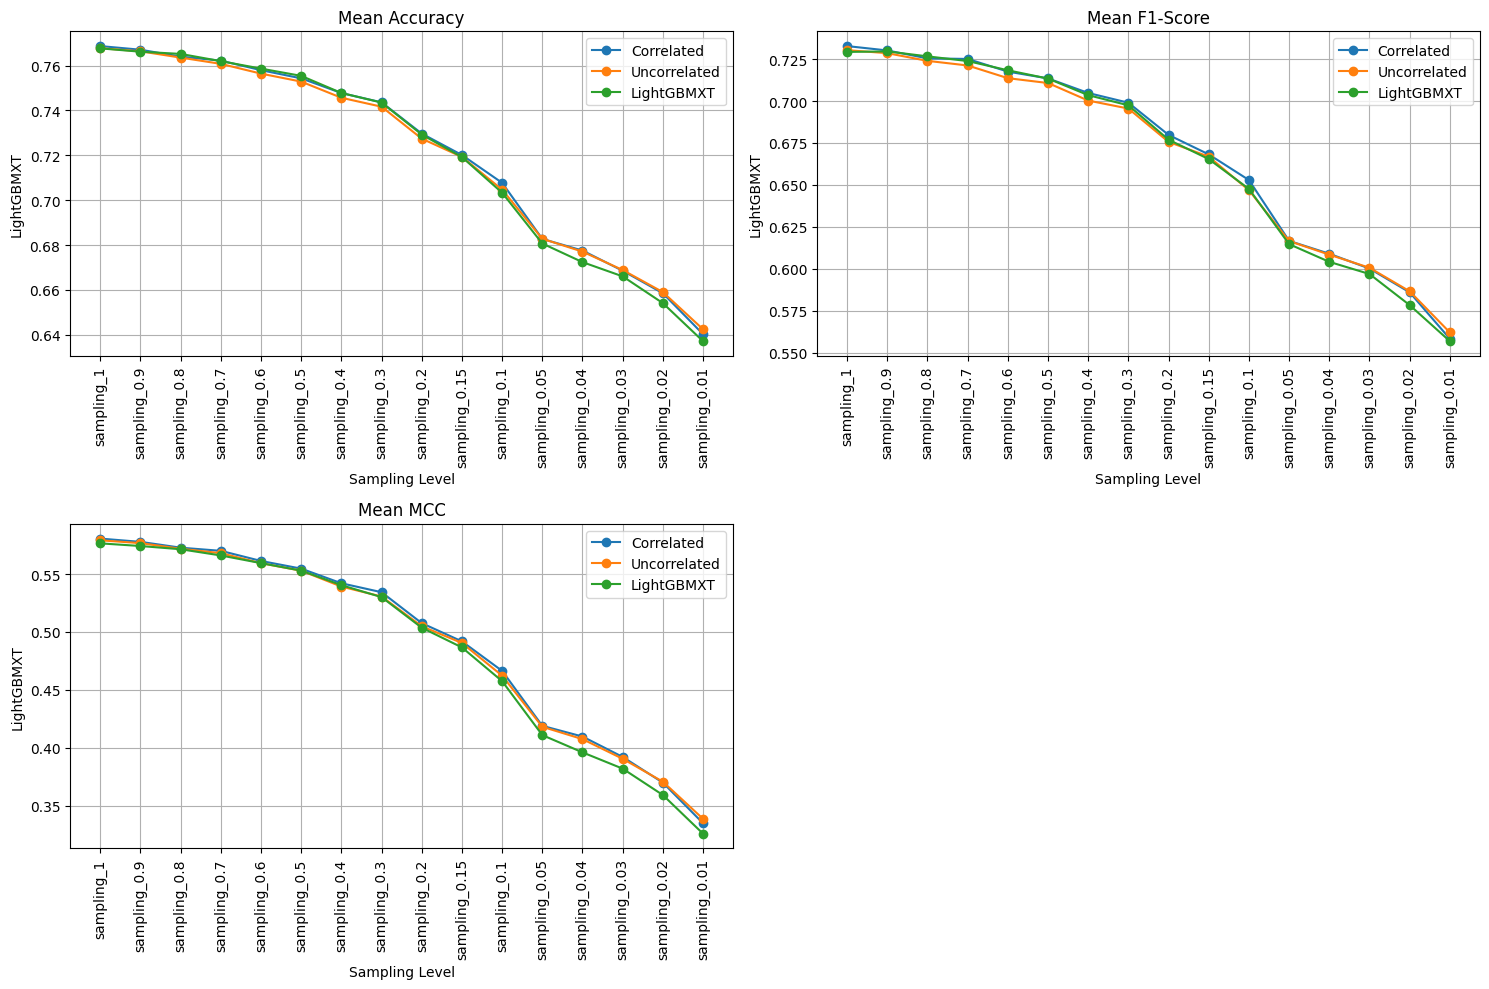

In [8]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.title("Mean Accuracy")
for rs, name in zip(rss_tries, files):
    plot_per_run_metric(rs, attr_name='per_run_balanced_accuracy', metric_name=name)

plt.subplot(2,2,2)
plt.title('Mean F1-Score')
for rs, name in zip(rss_tries, files):
    plot_per_run_metric(rs, attr_name='per_run_f1_score', metric_name=name)

plt.subplot(2,2,3)
plt.title('Mean MCC')
for rs, name in zip(rss_tries, files):
    plot_per_run_metric(rs, attr_name='per_run_mcc', metric_name=name)

### Heat map of the averaged signature

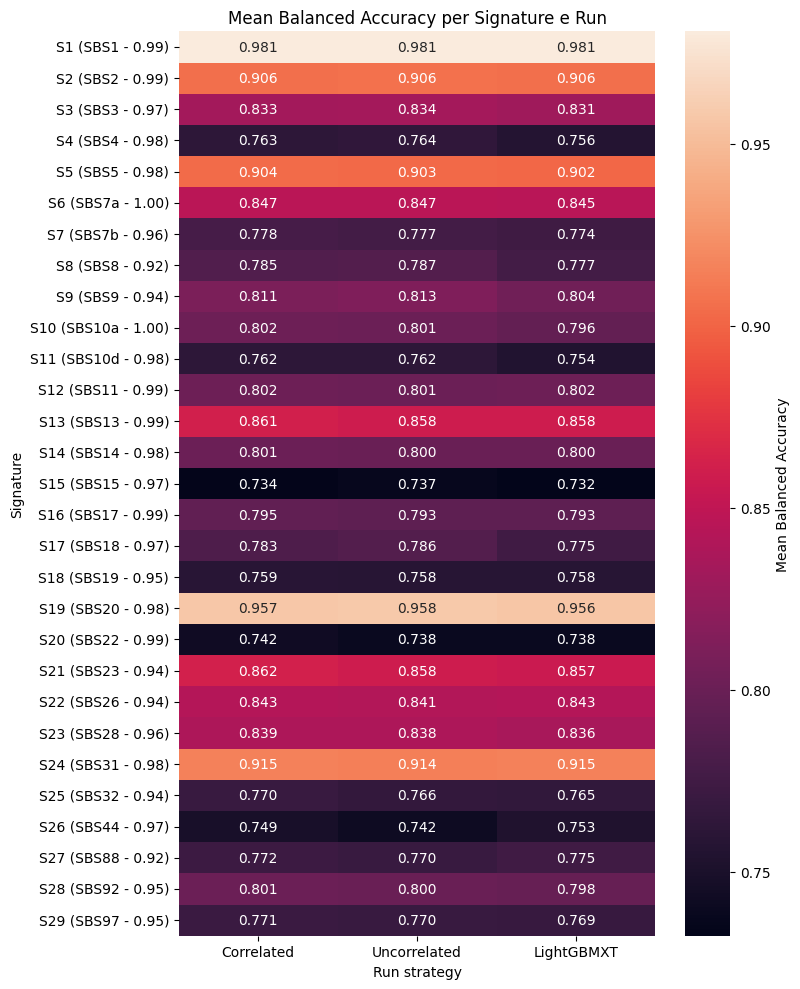

In [9]:
plot_signature_heatmap(rss_tries, files)

## Best Model Evaluations

In [10]:
rss = []
files = ['default_evaluations','cosmic_evaluations', 'reference_evaluations']
for f in files:
    rss.append(ResultsEvaluation(f))
for f, rs in zip (files, rss):
    print(f'{f} : {len(rs.run_labels)} runs')

default_evaluations : 23 runs
cosmic_evaluations : 10 runs
reference_evaluations : 5 runs


## Standar deviation of the signature per each sample across all runs

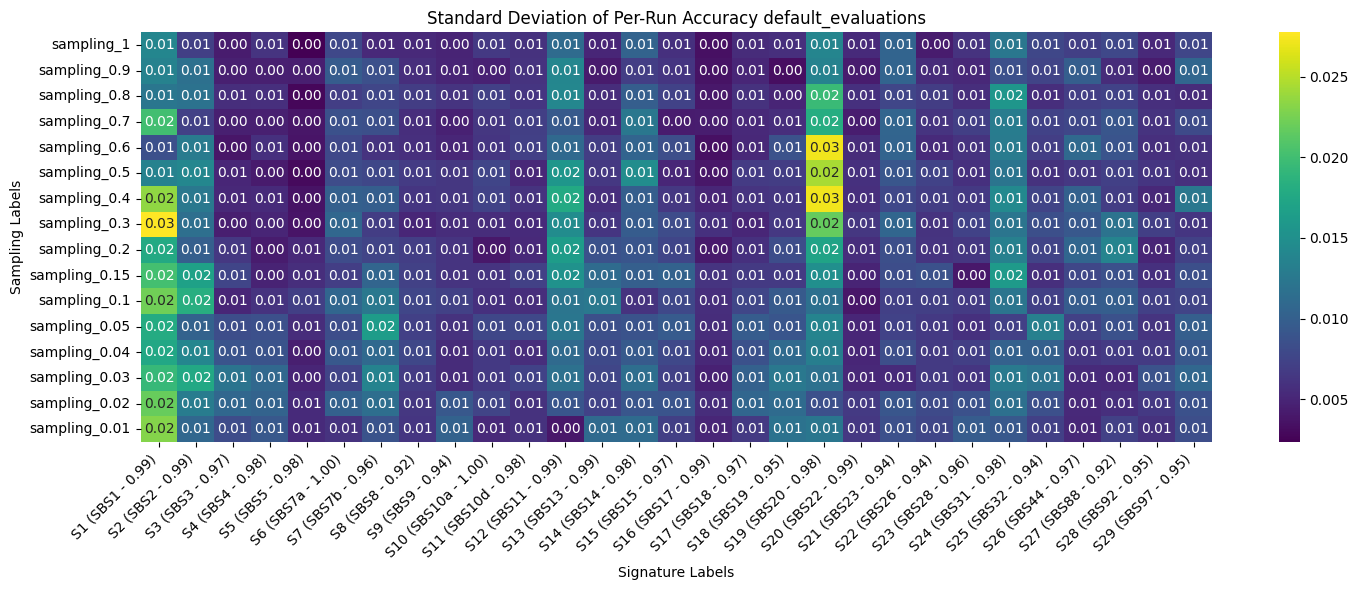

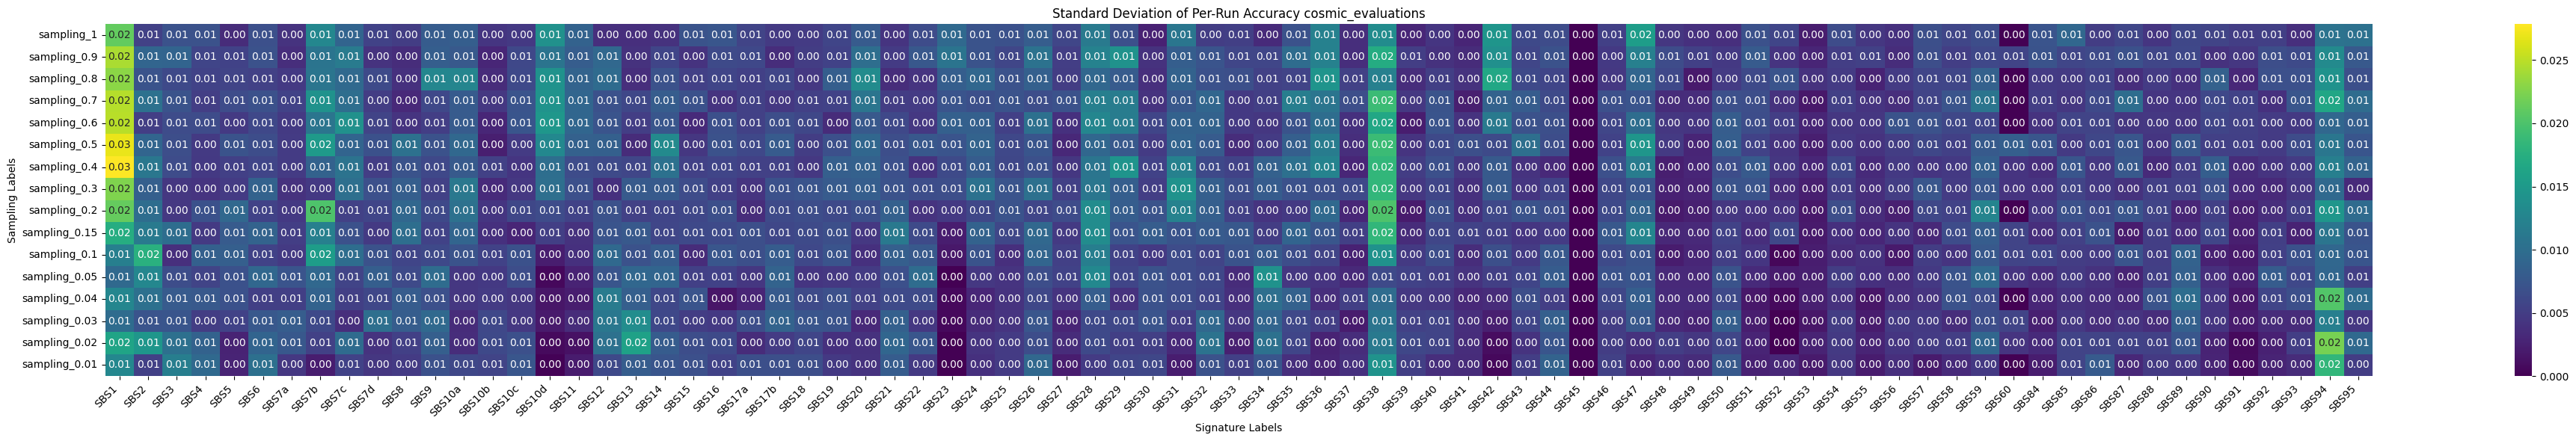

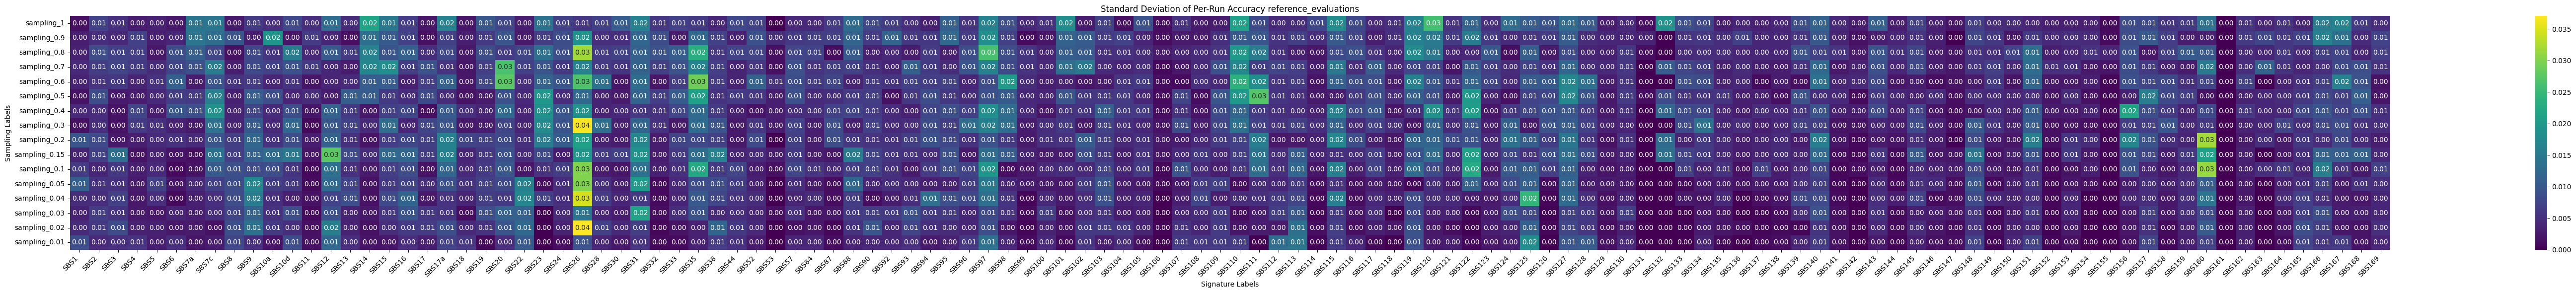

In [11]:
for rs, f in zip(rss, files):
    plot_standard_deviations(rs, f)

### Heat Map of the Accuracy for evey signature and every sample (Averaged Across Runs)

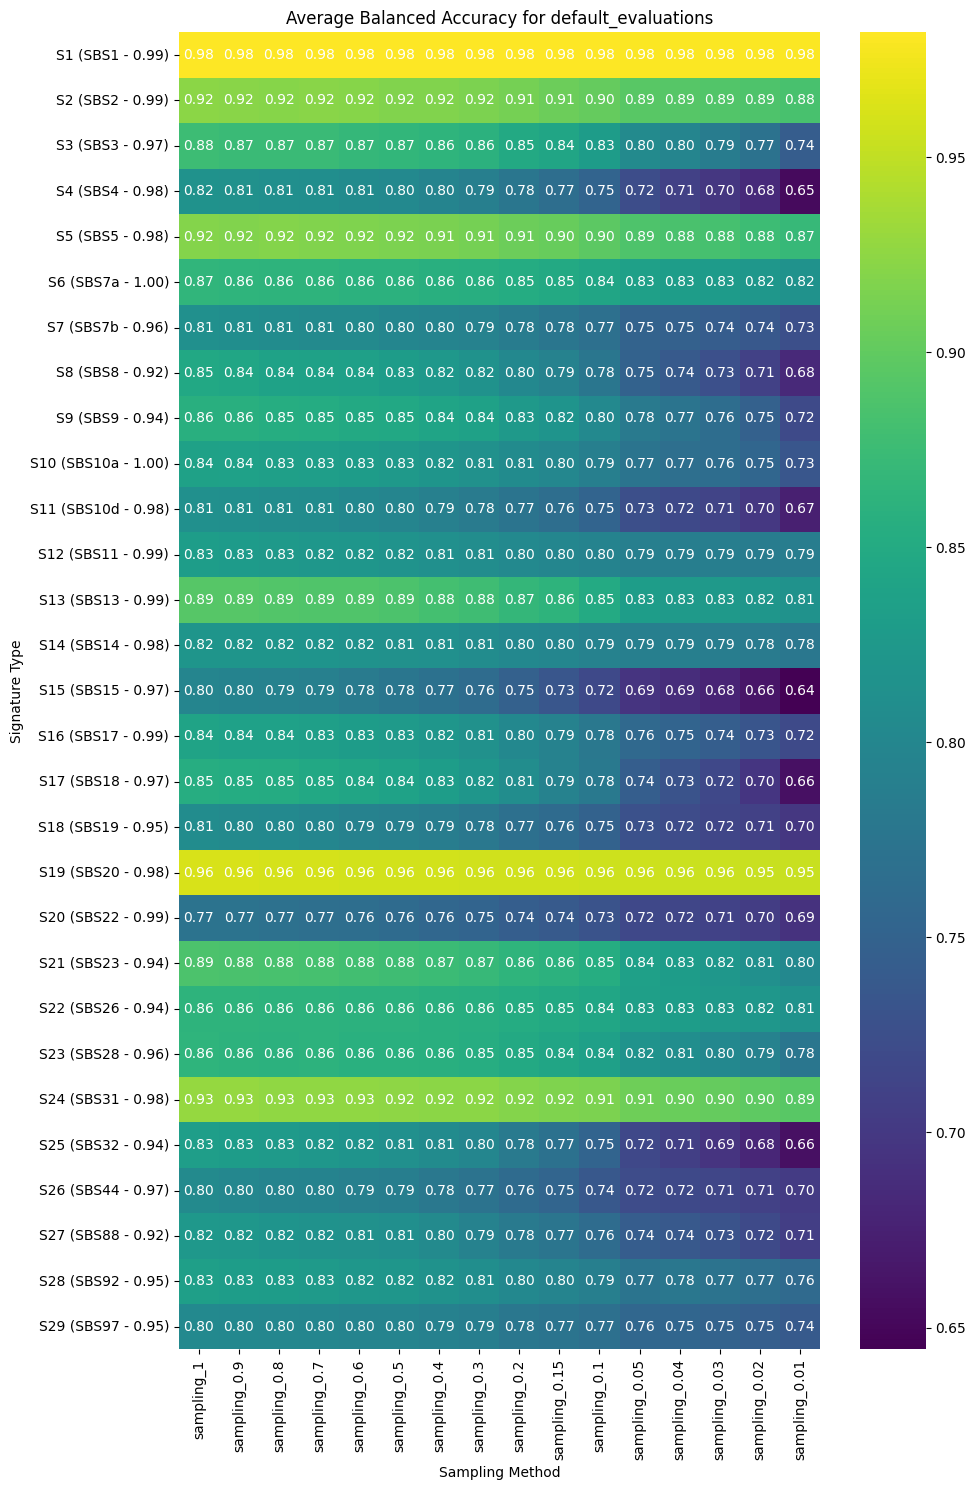

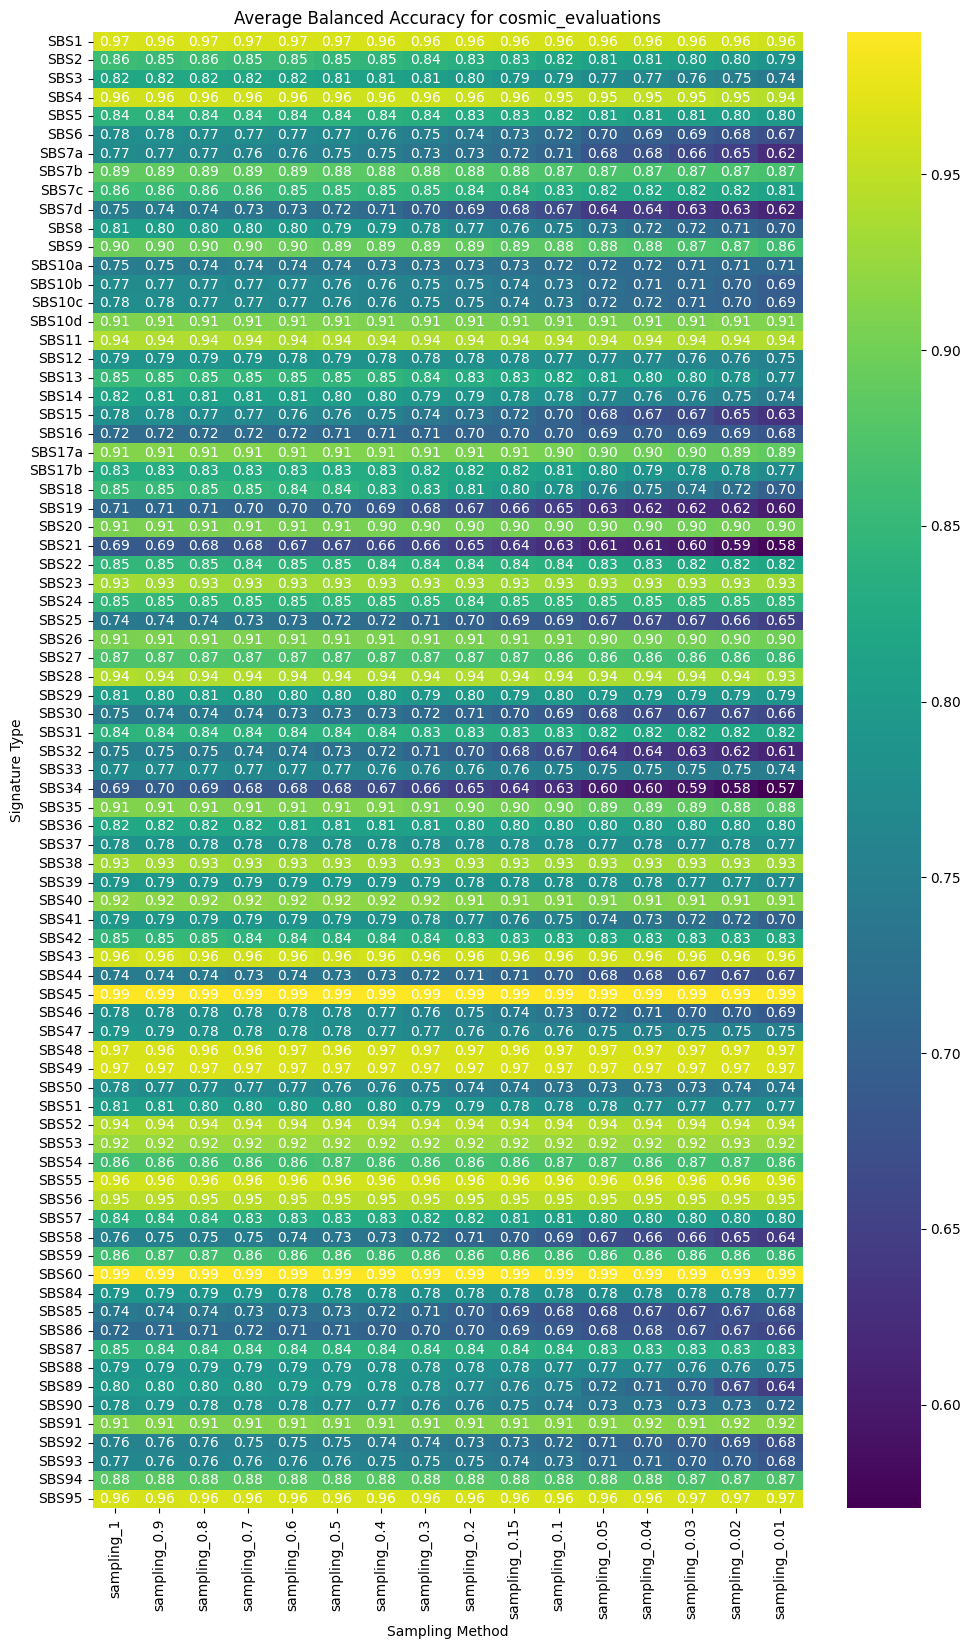

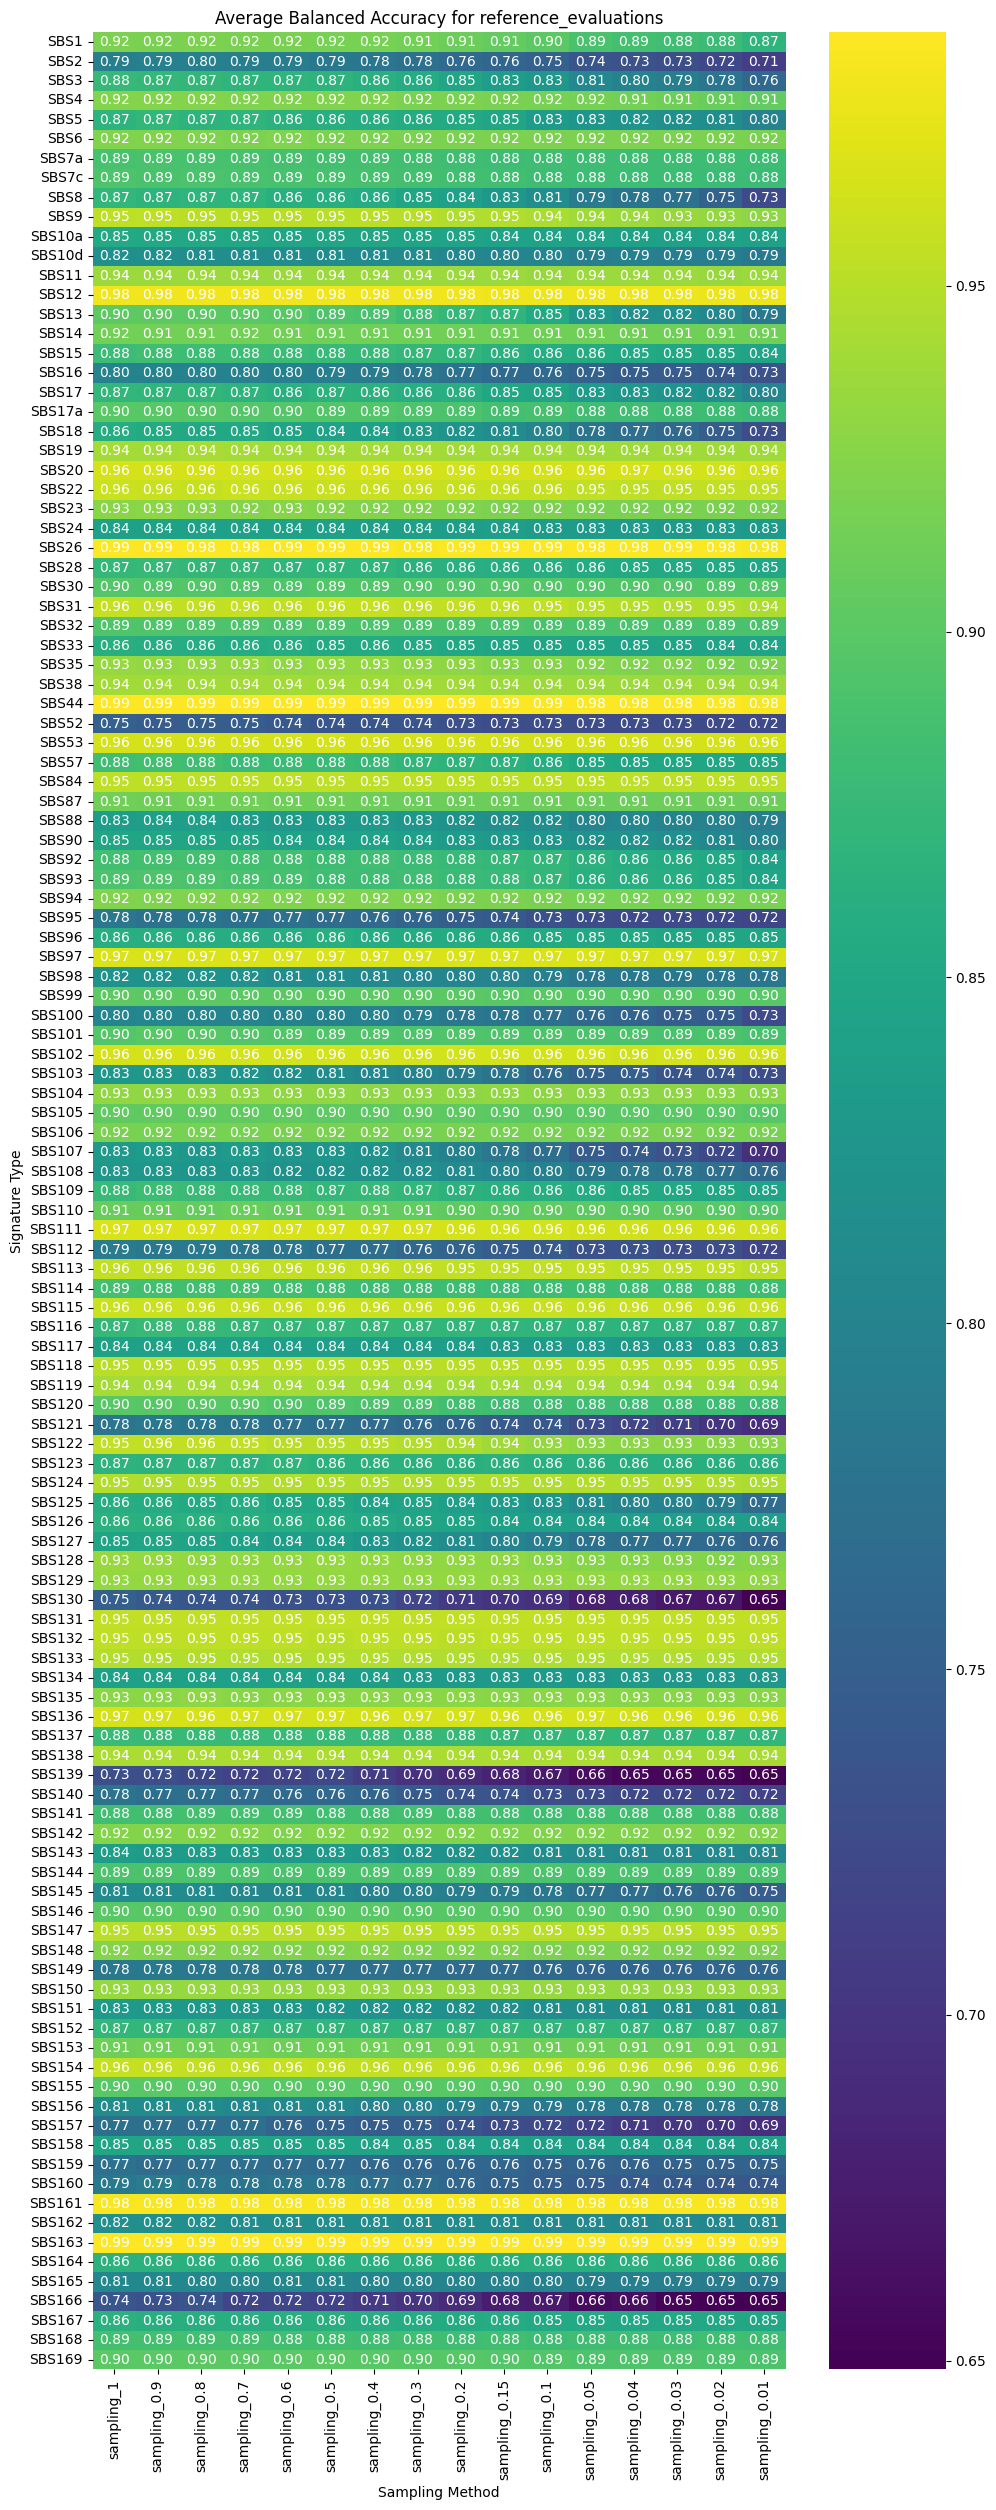

In [12]:
for rs, f in zip(rss, files):
    heat_map(rs, f)

### Accuracy of every Signature at the changing of the sample size

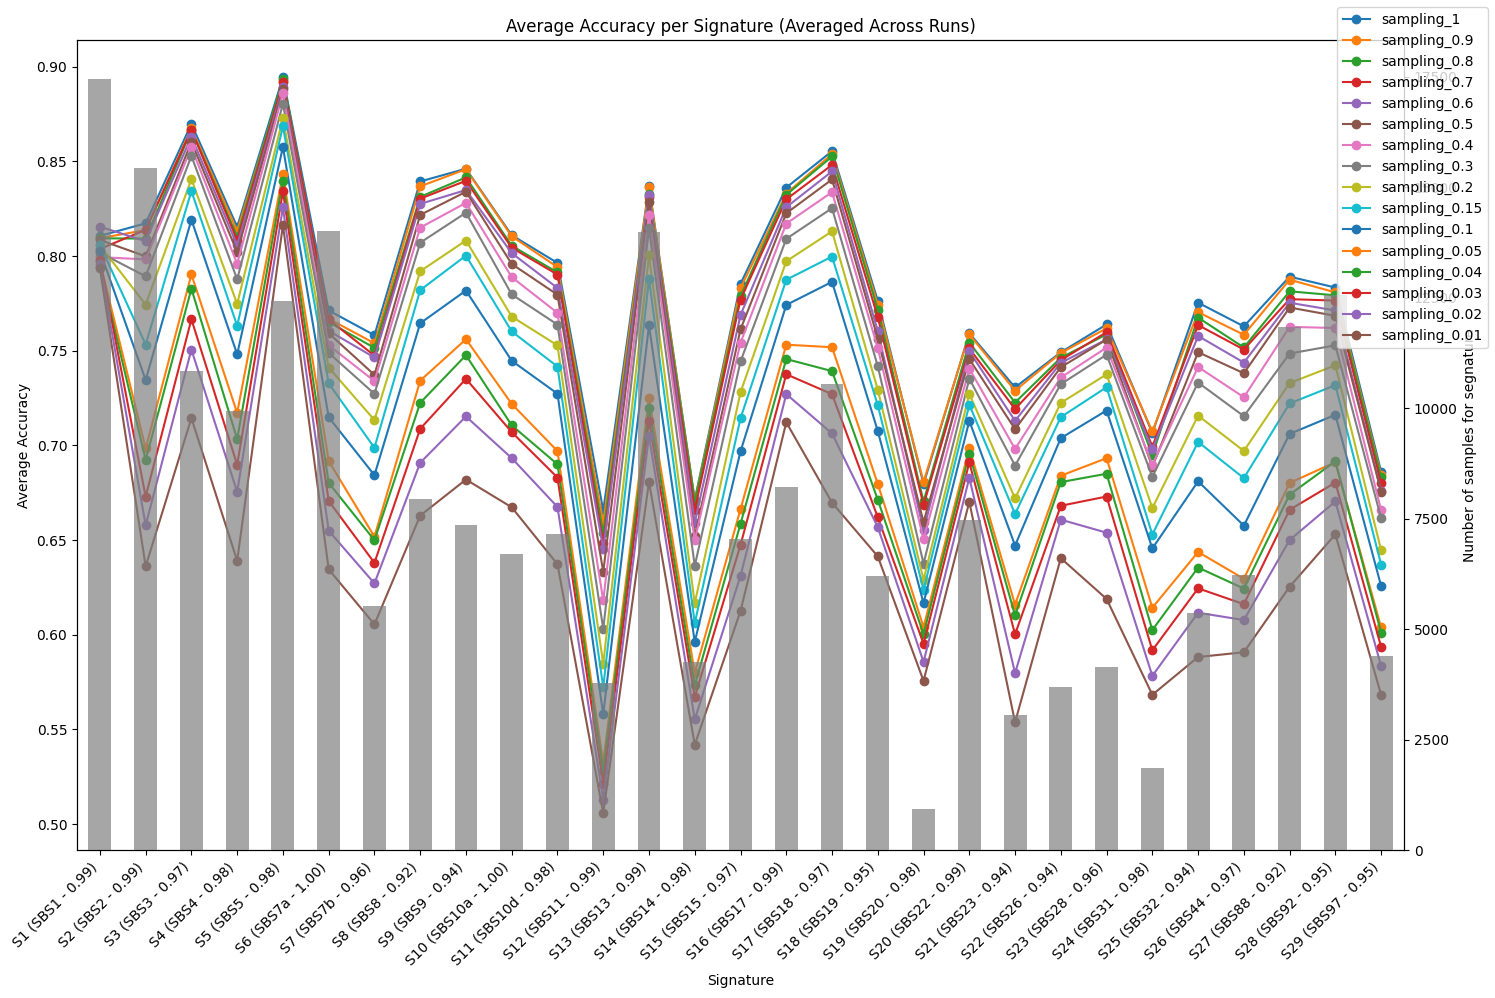

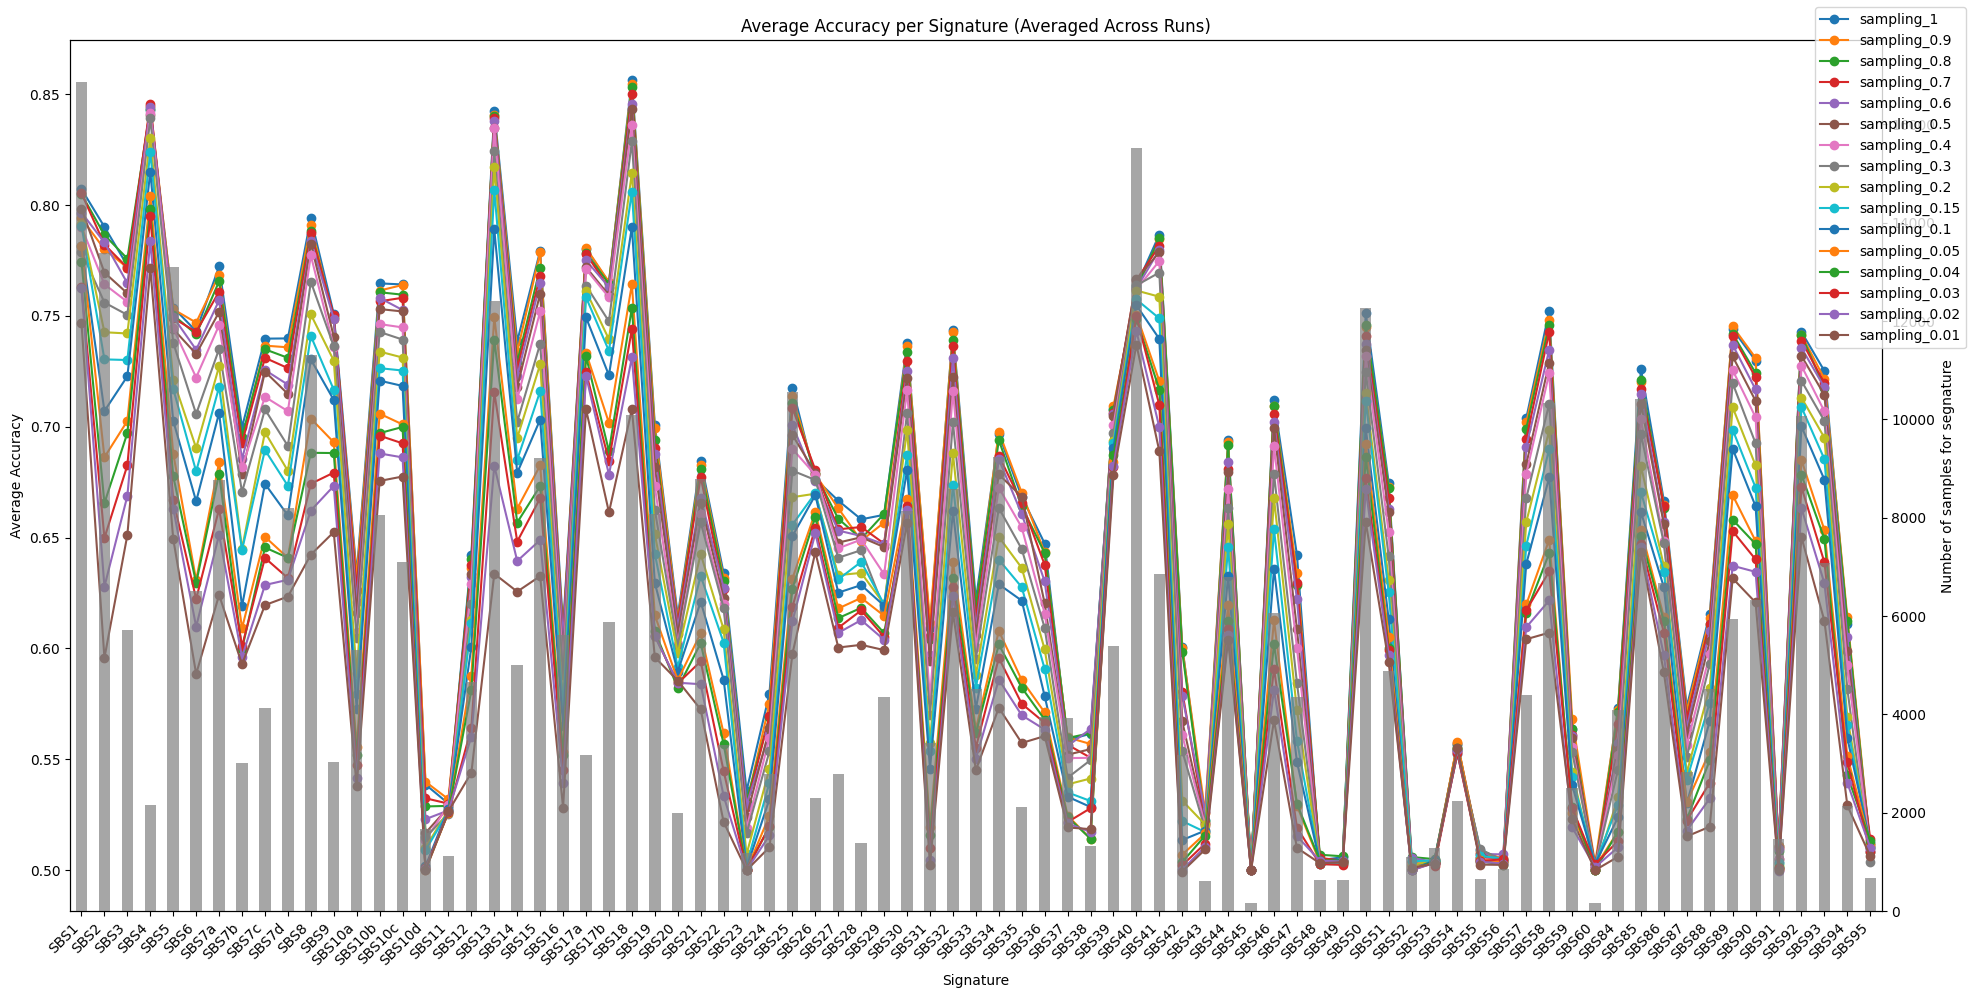

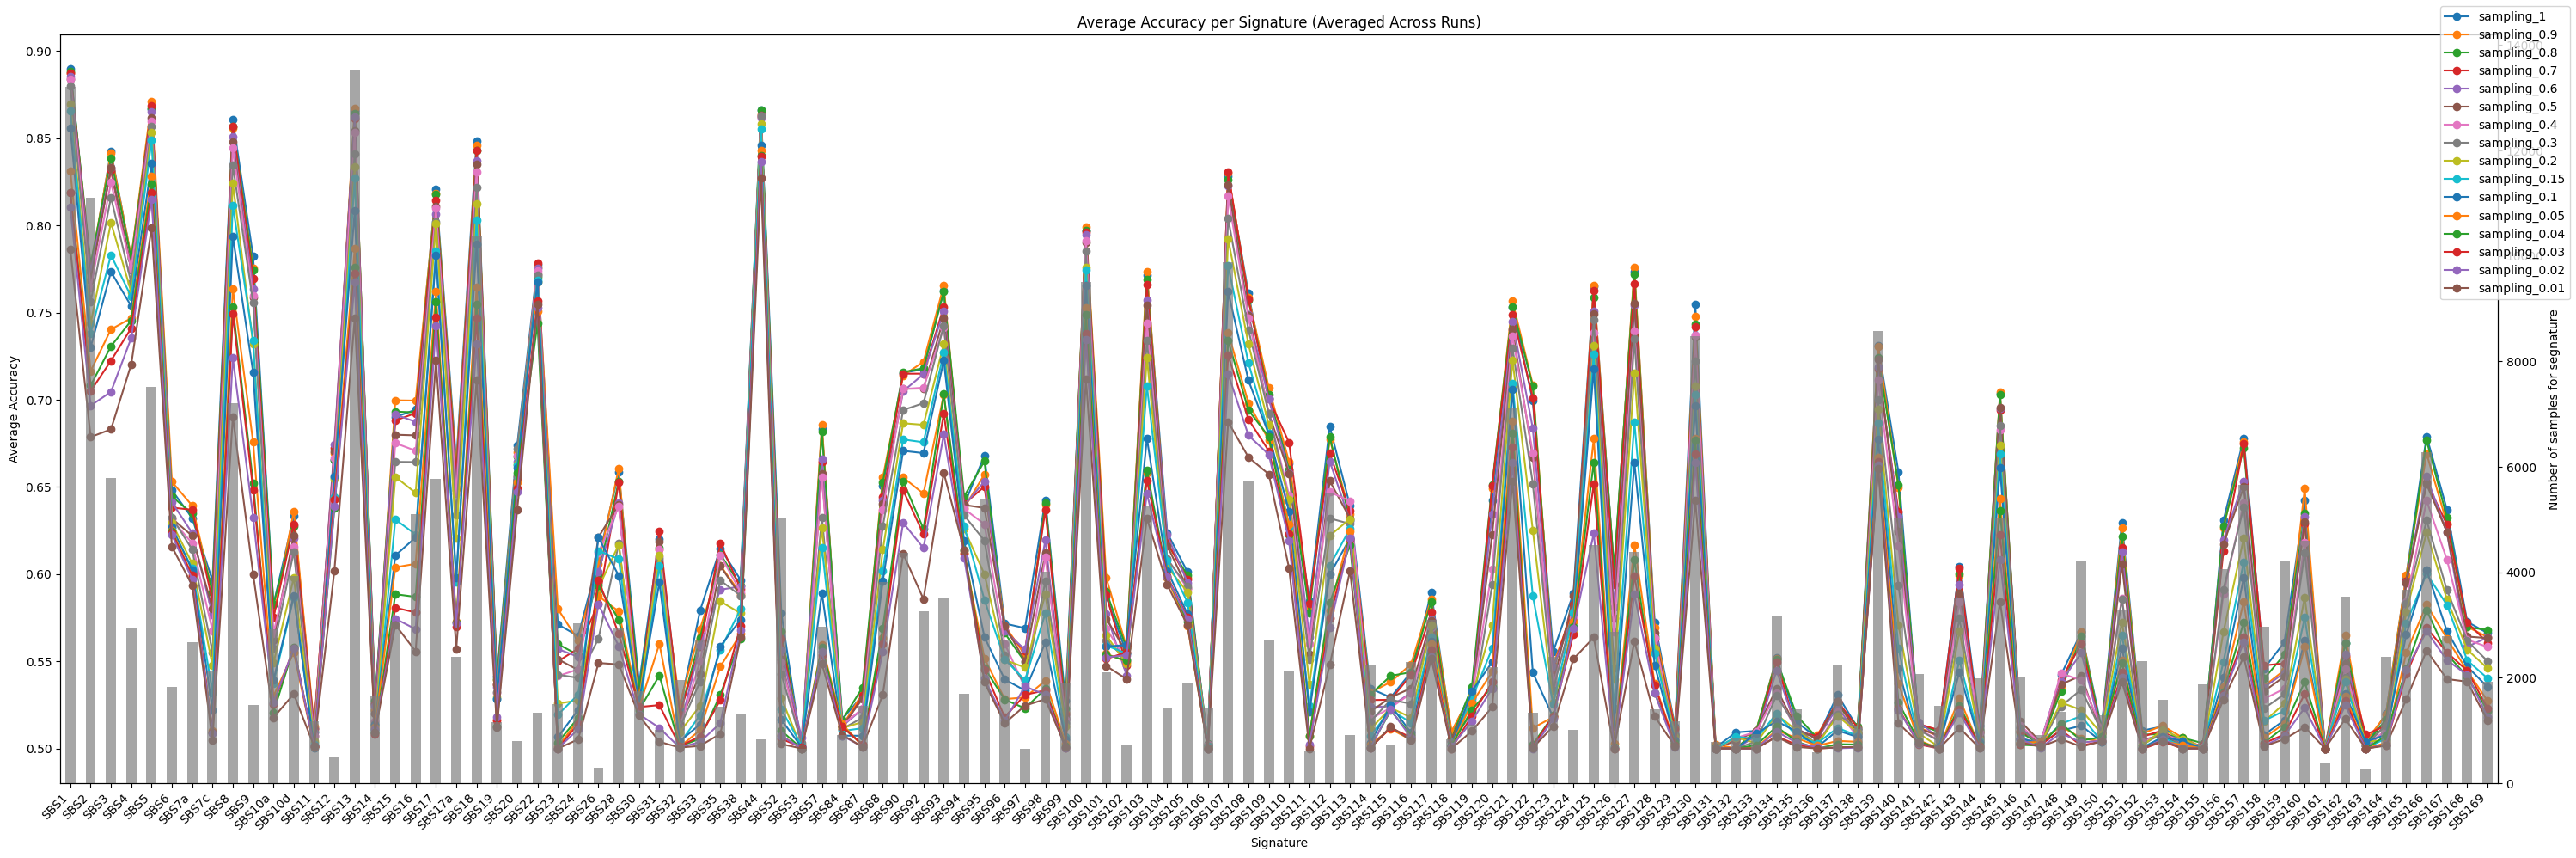

In [13]:
for rs,gt_labels in zip(rss, ['','_cosmic','_reference']):
    plot_all_signature_all_sampling_graph(rs, folder_name=gt_labels, bins=True)

### Average Accuracy, F1-Score and MCC per sampling size for the three ground truths

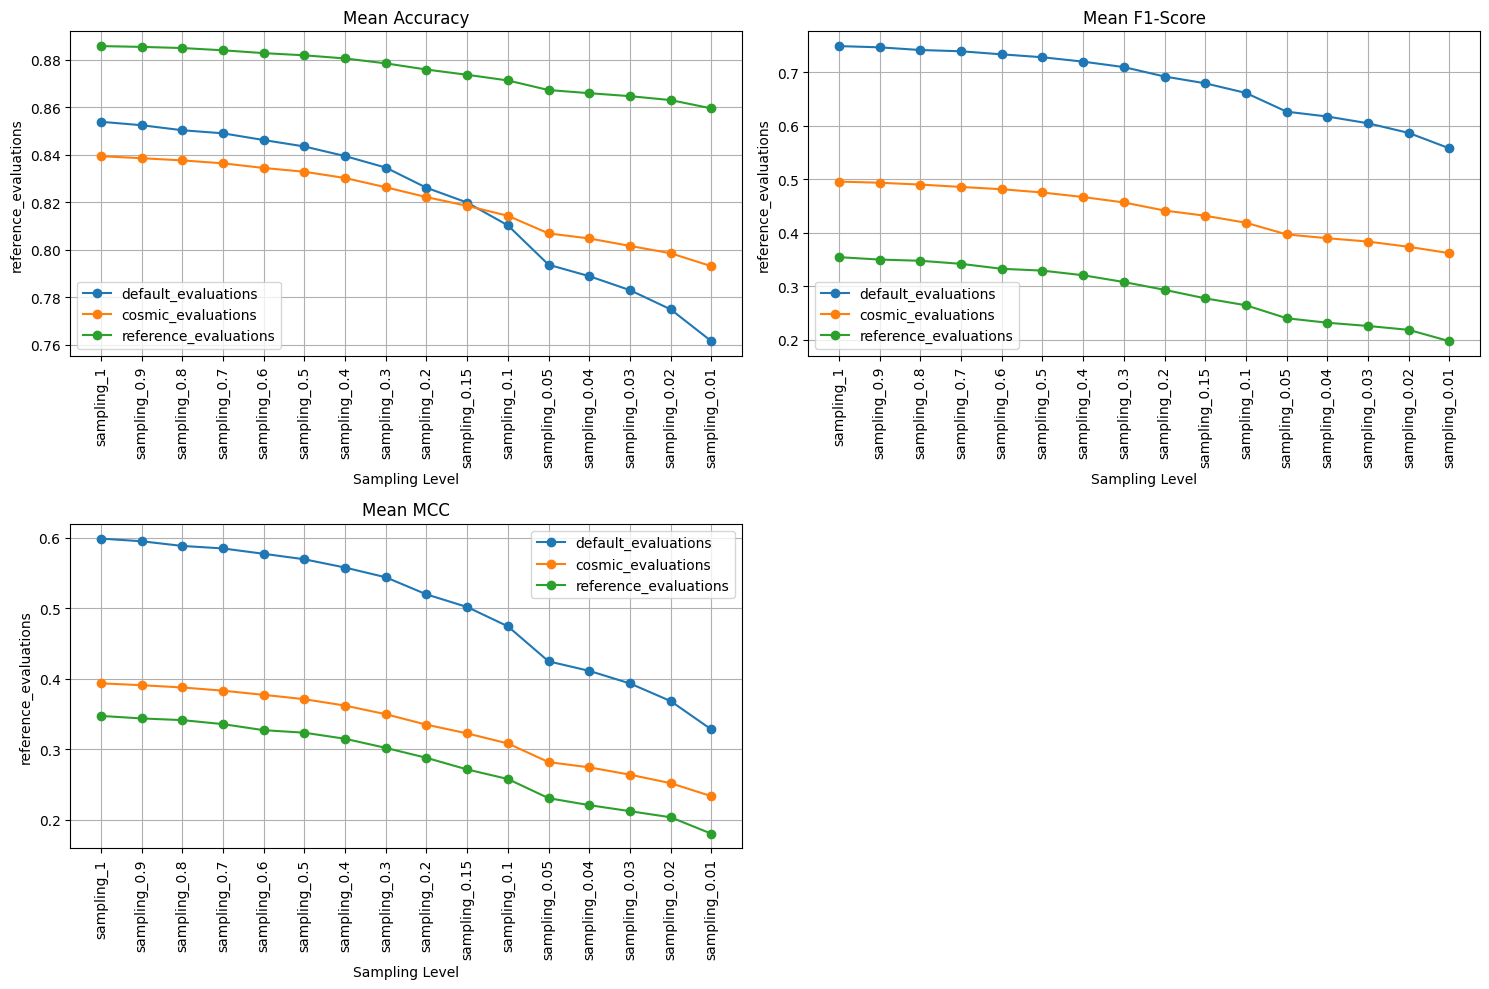

In [14]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.title("Mean Accuracy")
for rs, name in zip(rss, files):
    plot_per_run_metric(rs, attr_name='per_run_accuracy', metric_name=name)

plt.subplot(2,2,2)
plt.title('Mean F1-Score')
for rs, name in zip(rss, files):
    plot_per_run_metric(rs, attr_name='per_run_f1_score', metric_name=name)

plt.subplot(2,2,3)
plt.title('Mean MCC')
for rs, name in zip(rss, files):
    plot_per_run_metric(rs, attr_name='per_run_mcc', metric_name=name)

### Box-plot

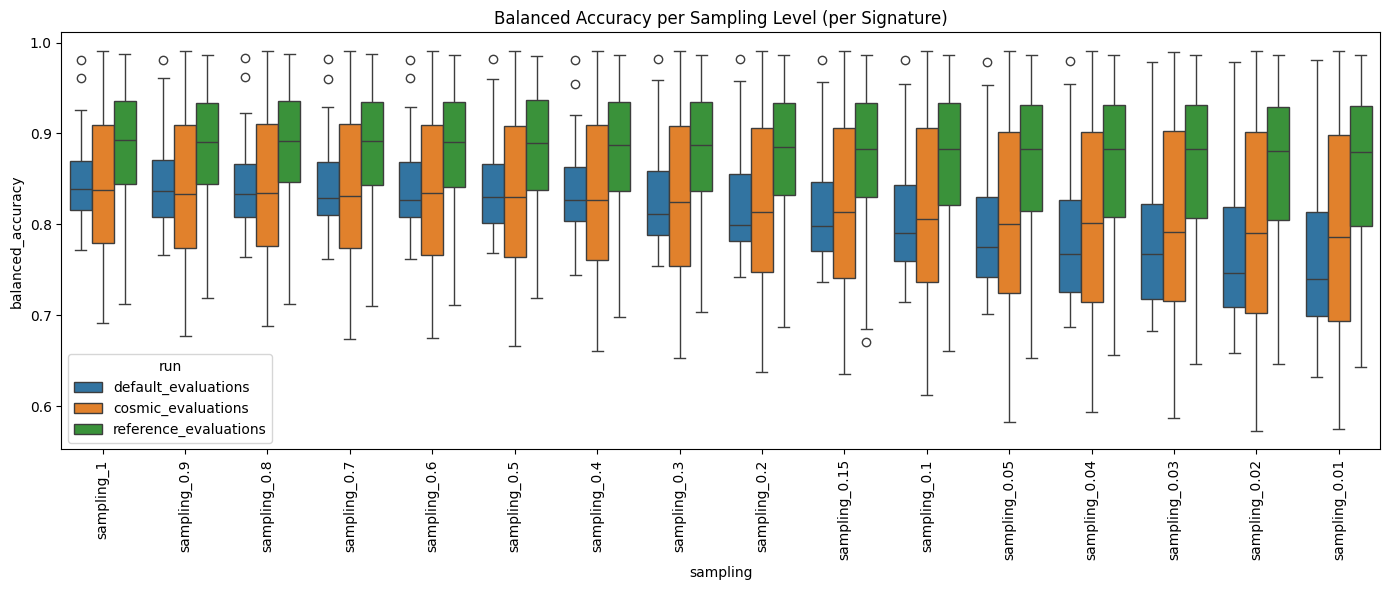

In [15]:
plot_boxplot_accuracy_by_sampling(rss, files)